In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from tqdm import tqdm
import os
import pickle

from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_samples, silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import AgglomerativeClustering

import ast
from sklearn.decomposition import PCA
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer


In [2]:
# 저장 폴더 생성
result_cluster_path = "./results_clustering"
result_tfidf_path = "./results_tfidf"

# 폴더 생성
if not os.path.exists(result_cluster_path):
    os.mkdir(result_cluster_path)
    print(f"'{result_cluster_path}' 폴더가 생성되었습니다.")
else:
    print(f"'{result_cluster_path}' 폴더가 이미 존재합니다.")
    
# 폴더 생성
if not os.path.exists(result_tfidf_path):
    os.mkdir(result_tfidf_path)
    print(f"'{result_tfidf_path}' 폴더가 생성되었습니다.")
else:
    print(f"'{result_tfidf_path}' 폴더가 이미 존재합니다.")

'./results_clustering' 폴더가 이미 존재합니다.
'./results_tfidf' 폴더가 이미 존재합니다.


## 1. 임베딩 파일(csv) 로드

In [3]:
emb_method = 'gem_128' # 'gem_128', 'kure_128', 'd2v_128'
clustering_method = 'agglomerative' # 'kmeans'; 'agglomerative'; 'hdbscan'

In [4]:
df = pd.read_csv('./embeddings/Embedding_%s.csv'%(emb_method), encoding='utf-8-sig')
#df.head()

In [5]:
df.columns.values[-1] = 'vector'
#df.head()

In [6]:
# 데이터 변환 (문자열 -> 리스트)
# df['vector'] = df['vector'].apply(ast.literal_eval)
df['vector'] = df['vector'].apply(lambda x: np.fromstring(x.strip('[]'), sep=' '))
df['token'] = df['token'].apply(ast.literal_eval)

## 2. 클러스터링

### 2.1 덴드로그램 확인

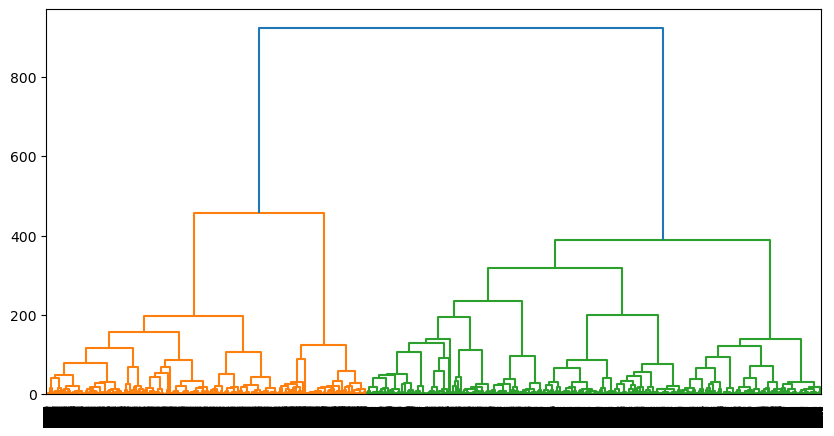

In [7]:
model_linkage = linkage(list(df['vector']), 'ward')

plt.figure(figsize=(10, 5))
dendrogram(model_linkage,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts = False)

plt.savefig("%s/ActorClustering_%s_%s_dendrogram.png"%(result_cluster_path, clustering_method, emb_method), dpi=300, bbox_inches='tight')
plt.show()

### 2.2 클러스터수(k)에 따른 `실루엣 지수`, `SSE` 그래프 시각화

In [8]:
def calculate_sse(X, labels, n_clusters):
    sse = 0
    for i in range(n_clusters):
        # 각 군집에 속한 데이터 포인트 추출
        cluster_points = X[labels == i]
        # 군집 중심(평균) 계산
        centroid = np.mean(cluster_points, axis=0)
        # 중심과의 거리 제곱 합 계산
        sse += np.sum((cluster_points - centroid) ** 2)
    return sse

In [9]:
X = list(df['vector'])

In [10]:
# 실루엣 지수, sse
n_cluster = []

cluster_label_list = [] # 클러스터수 마다의 클러스터링 결과 저장

clustering_sil = []
clustering_sil_samples = []
clustering_sse = []

for i in tqdm(range(2, 10)):
    cluster = AgglomerativeClustering(n_clusters = i, linkage='ward')
    cluster_label = cluster.fit_predict(X)
    
    sil = silhouette_score(X, cluster_label)
    sil_samples = silhouette_samples(X, cluster_label)
    sse_value = calculate_sse(np.array(X), cluster_label, i)
    
    
    cluster_label_list.append(cluster_label)
    n_cluster.append(i)
    clustering_sil.append(sil)
    clustering_sil_samples.append(sil_samples)
    clustering_sse.append(sse_value)
    

# 클러스터수 마다의 클러스터링 결과 저장 (pickle)
with open("%s/ActorClustering_%s_%s_clustering_n2to9.pkl"%(result_cluster_path, clustering_method, emb_method), 'wb') as f:
    pickle.dump(cluster_label_list, f)

100%|██████████| 8/8 [57:13<00:00, 429.16s/it]


#### SSE 시각화

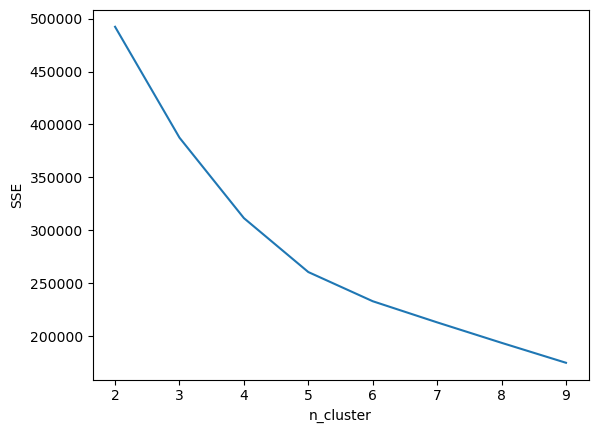

In [11]:
# 시각화 (SSE)
plt.plot(n_cluster, clustering_sse)
plt.xlabel("n_cluster")
plt.ylabel("SSE")

plt.savefig("%s/ActorClustering_%s_%s_Elbow_SSE_plot.png"%(result_cluster_path, clustering_method, emb_method), dpi=300, bbox_inches='tight')
plt.show()

In [12]:
result = pd.DataFrame([n_cluster, clustering_sse]).T
result.columns = ['n_cluster', 'sse']
result

,n_cluster,sse
0,2.0,492242.289949
1,3.0,387515.851481
2,4.0,311574.718388
3,5.0,260650.703438
4,6.0,233096.606769
5,7.0,213131.476698
6,8.0,193819.496697
7,9.0,174979.017600


#### 실루엣계수 시각화

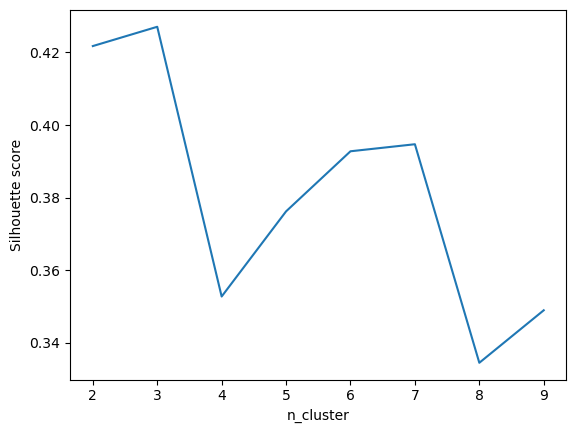

In [13]:
# 시각화 (실루엣계수)
plt.plot(n_cluster, clustering_sil)
plt.xlabel("n_cluster")
plt.ylabel("Silhouette score")

plt.savefig("%s/ActorClustering_%s_%s_Elbow_Silhouette_plot.png"%(result_cluster_path, clustering_method, emb_method), dpi=300, bbox_inches='tight')
plt.show()

In [14]:
result = pd.DataFrame([n_cluster, clustering_sil]).T
result.columns = ['n_cluster', 'sse']
result

,n_cluster,sse
0,2.0,0.421766
1,3.0,0.427078
2,4.0,0.352781
3,5.0,0.376235
4,6.0,0.392787
5,7.0,0.394725
6,8.0,0.334528
7,9.0,0.348991


### 2.3 클러스터수(k)에 따른 `실루엣계수 분포 / PCA` 시각화, `TF-IDF` 계산

In [15]:
for idx, cluster_label in enumerate(cluster_label_list):
    nc = idx+2 # 2~9
    
    df_clusterd = df.copy()
    df_clusterd['cluster'] = cluster_label
    
    df_si = df_clusterd.copy()
    # score_samples = silhouette_samples(list(df_si['vector']), cluster_label)
    
    sil_samples = clustering_sil_samples[idx]

    # df_si['cluster'] = cluster_label
    df_si['silhouette'] = sil_samples
    df_si[['cluster', 'silhouette']]
    
    ''' (1) 실루엣계수 분포 시각화 '''
    clusters = df_si['cluster'].unique()
    clusters.sort()

    # 전체 실루엣 평균
    silhouette_avg = df_si['silhouette'].mean()

    fig, ax = plt.subplots(figsize=(8, 6))

    y_lower = 10  # y축에서 각 클러스터 블록이 시작되는 높이

    for cluster in clusters:
        # 해당 cluster 데이터만 추출
        cluster_values = df_si[df_si['cluster'] == cluster]['silhouette'].values

        # 오름차순 정렬(실루엣 플롯은 sorted)
        cluster_values.sort()

        size_cluster = len(cluster_values)
        y_upper = y_lower + size_cluster

        # 플롯
        color = plt.cm.nipy_spectral(float(cluster) / len(clusters))
        ax.fill_betweenx(np.arange(y_lower, y_upper),
                        0, cluster_values,
                        facecolor=color, alpha=0.7)

        # 클러스터 번호 표시
        ax.text(-0.05, y_lower + 0.5 * size_cluster, str(cluster))

        # 다음 클러스터 영역으로 y 기준 이동
        y_lower = y_upper + 10

    # 평균 실루엣 점수 수직선
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax.set_xlabel("Silhouette coefficient values")
    ax.set_ylabel("Cluster label")
    ax.set_title(f"Silhouette plot (k = {len(clusters)}, avg = {silhouette_avg:.3f})")
    ax.set_yticks([])  # y축 눈금 제거
    ax.set_xticks(np.linspace(0, 1, 6))

    plt.savefig("%s/ActorClustering_%s_%s_Silhouette_distribution_plot_k%s.png"%(result_cluster_path, clustering_method, emb_method, nc), dpi=300, bbox_inches='tight')
    # plt.show()
    plt.close()


    ''' (2) 클러스터링 결과 csv 저장 '''
    df_clusterd.to_csv("%s/ActorClustering_%s_%s_k%s.csv"%(result_cluster_path, clustering_method, emb_method, nc), index=False, encoding='utf-8-sig')
    
    
    ''' (3) PCA 시각화 '''
    df_v = df_clusterd[['vector', 'cluster']]
        
    # 1) vector 컬럼을 (n_samples, 300) 행렬로 만들기
    X = np.vstack(df_v['vector'].values)   # shape: (N, 300)

    # 2) cluster 라벨
    labels = df_v['cluster'].values        # shape: (N,)

    # 3) PCA로 2차원으로 축소
    pca = PCA(n_components=2, random_state=0)
    X_pca = pca.fit_transform(X)           # shape: (N, 2)

    # 4) 결과를 df_v에 붙여두면 나중에 분석하기 편함
    df_v['pca1'] = X_pca[:, 0]
    df_v['pca2'] = X_pca[:, 1]
    
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(df_v['pca1'], df_v['pca2'],
                        c=df_v['cluster'], alpha=0.7)

    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.title("PCA Visualization")

    cbar = plt.colorbar(scatter)
    cbar.set_label("Cluster")

    plt.savefig("%s/ActorClustering_%s_%s_PCA_plot_k%s.png"%(result_cluster_path, clustering_method, emb_method, nc), dpi=300, bbox_inches='tight')
    # plt.show()
    plt.close()
    
    
    ''' (4) TF-IDF 계산 및 저장 '''
    all_document = []
    for i in df_clusterd['cluster'].unique():
        print(i)
        pos_tagging = df_clusterd[df_clusterd['cluster'] == i]['token']
        
        document = ''
        for pos in pos_tagging:
            doc = " ".join(pos) + " "
            document += doc
            
        all_document.append(document)
        
    # TF-IDF 벡터라이저 선언
    vectorizer = TfidfVectorizer()
    # TF-IDF 매트릭스 핏
    tfidf_matrix = vectorizer.fit_transform(all_document)
    
    # 키워드 도출
    feature_name = vectorizer.get_feature_names_out()
    
    # TF-IDF 값
    tfidf_value = tfidf_matrix.toarray()
    
    # 데이터프레임으로 만들고 정렬하기
    tfidf_df = pd.DataFrame(tfidf_value, columns=feature_name)

    # 인덱스 부여 (cluster 번호)
    tfidf_df.index = df_clusterd['cluster'].unique()
    
    # 행열 전환
    tfidf_df_T = tfidf_df.T


    for i in tfidf_df_T.columns:
        # 점수 정렬
        tfidfvalue = tfidf_df_T[i].sort_values(ascending=False) # 내림차순 정렬
        # 데이터프레임으로 다시 변환
        data = {'tfidf_word': tfidfvalue.index, 'tfidf': tfidfvalue.values}
        data_df = pd.DataFrame(data)
        
        data_df.to_csv(f'{result_tfidf_path}/TFIDF_{clustering_method}_{emb_method}_k{nc}_cluster{i}.csv', encoding='utf-8-sig')

/tmp/ipykernel_2791306/464173163.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_v['pca1'] = X_pca[:, 0]
/tmp/ipykernel_2791306/464173163.py:82: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_v['pca2'] = X_pca[:, 1]


1
0


/tmp/ipykernel_2791306/464173163.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_v['pca1'] = X_pca[:, 0]
/tmp/ipykernel_2791306/464173163.py:82: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_v['pca2'] = X_pca[:, 1]


0
2
1


/tmp/ipykernel_2791306/464173163.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_v['pca1'] = X_pca[:, 0]
/tmp/ipykernel_2791306/464173163.py:82: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_v['pca2'] = X_pca[:, 1]


...

3
2
0
4
1
6
5


/tmp/ipykernel_2791306/464173163.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_v['pca1'] = X_pca[:, 0]
/tmp/ipykernel_2791306/464173163.py:82: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_v['pca2'] = X_pca[:, 1]


3
2
1
4
0
6
7
5


/tmp/ipykernel_2791306/464173163.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_v['pca1'] = X_pca[:, 0]
/tmp/ipykernel_2791306/464173163.py:82: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_v['pca2'] = X_pca[:, 1]


1
2
0
4
3
6
8
7
5
